In [1]:
pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 106.7 MB/s eta 0:00:00


In [2]:
import re
import nltk
import pymorphy3 #приводит к начальной форме слова
import pandas as pd

from tqdm import tqdm
from nltk.stem.snowball import RussianStemmer #отрезает лишнее от корня слова
from sklearn.model_selection import train_test_split

import torch

from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader

In [3]:
tqdm.pandas()
nltk.download('punkt') #разделение предложения по словам

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
train_dataframe = pd.read_csv("./train.csv").iloc[:2000]
valid_dataframe = pd.read_csv("./test.csv").iloc[:400]

In [5]:
train_dataframe.head()

,oid,category,text
0,365271984,winter_sport,Волшебные фото Виктория Поплавская ЕвгенияМедв...
1,503385563,extreme,Возвращение в подземелье Треша 33 Эйфория тупо...
2,146016084,football,Лучшие чешские вратари – Доминик Доминатор Гаш...
3,933865449,boardgames,Rtokenoid Warhammer40k валрак решил нас подкор...
4,713550145,hockey,Шестеркин затаскивает Рейнджерс в финал Восточ...


In [ ]:
# train_dataframe

In [6]:
def preproc(text):
  text = text.lower()
  text = re.sub(r"([^\w\s]\s)", r" \1", text)
  text = re.sub(r"(\d)\.", r"\1 . ", text)
  text = re.sub(r"\s+", r" ", text)
  text = text.strip()
  text = text.split(" ")

  morph = pymorphy3.MorphAnalyzer()
  text = [morph.parse(word)[0].normal_form for word in text]

  # stemmer = RussianStemmer()
  # stemmed_words = [stemmer.stem(word) for word in text]

  return text

def slicingWindow(sequence):
  pairs = []
  for index, word in enumerate(sequence):
    for jndex in [-2, -1, 1, 2]:
      if 0 <= index+jndex < len(sequence):
        pairs.append((sequence[index], sequence[index+jndex]))
  return pairs

In [7]:
preproc("Волшебные фото Виктория Поплавская Евгения. 2.3.1")

['волшебный',
 'фото',
 'виктория',
 'поплавский',
 'евгений',
 '.',
 '2',
 '.',
 '3',
 '.',
 '1']

In [8]:
text = "   Волшебные фото Виктория Поплавская Евгения.   2.3.1.  "
sequence_of_words = preproc(text)
slicingWindow(sequence_of_words)

[('волшебный', 'фото'),
 ('волшебный', 'виктория'),
 ('фото', 'волшебный'),
 ('фото', 'виктория'),
 ('фото', 'поплавский'),
 ('виктория', 'волшебный'),
 ('виктория', 'фото'),
 ('виктория', 'поплавский'),
 ('виктория', 'евгений'),
 ('поплавский', 'фото'),
 ('поплавский', 'виктория'),
 ('поплавский', 'евгений'),
 ('поплавский', '.'),
 ('евгений', 'виктория'),
 ('евгений', 'поплавский'),
 ('евгений', '.'),
 ('евгений', '2'),
 ('.', 'поплавский'),
 ('.', 'евгений'),
 ('.', '2'),
 ('.', '.'),
 ('2', 'евгений'),
 ('2', '.'),
 ('2', '.'),
 ('2', '3'),
 ('.', '.'),
 ('.', '2'),
 ('.', '3'),
 ('.', '.'),
 ('3', '2'),
 ('3', '.'),
 ('3', '.'),
 ('3', '1'),
 ('.', '.'),
 ('.', '3'),
 ('.', '1'),
 ('.', '.'),
 ('1', '3'),
 ('1', '.'),
 ('1', '.'),
 ('.', '.'),
 ('.', '1')]

In [9]:
train_pairs = train_dataframe["text"].progress_apply(preproc).progress_apply(slicingWindow).explode().tolist()
valid_pairs = valid_dataframe["text"].progress_apply(preproc).progress_apply(slicingWindow).explode().tolist()

100%|██████████| 400/400 [00:00<00:00, 18404.55it/s]


In [13]:
train_pairs[:10]

[('волшебный', 'фото'),
 ('волшебный', 'виктория'),
 ('фото', 'волшебный'),
 ('фото', 'виктория'),
 ('фото', 'поплавский'),
 ('виктория', 'волшебный'),
 ('виктория', 'фото'),
 ('виктория', 'поплавский'),
 ('виктория', 'евгениямедведев'),
 ('поплавский', 'фото')]

In [15]:
class MyDataset(torch.utils.data.Dataset):
  def __init__(self, pairs):
    self.pairs = pairs

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, index):
    return self.pairs[index][0], self.pairs[index][1]

In [16]:
batch_size = 16
train_dataset = MyDataset(train_pairs)
valid_dataset = MyDataset(valid_pairs)

In [17]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

In [18]:
class Tokenizer:
  def __init__(self, set_of_words):
    self.__word2index = {}
    self.__index2word = {}
    for index, value in enumerate(set_of_words):
      self.__word2index[value] = index
      self.__index2word[index] = value

  def __call__(self, sequence):
    tokens = []
    for word in sequence:
      try:
        tokens.append(self.__word2index[word.lower()])
      except:
        raise ValueError("Такого слова нет в токенизаторе")
    return torch.tensor(tokens)

  def decode(self, sequence):
    words = []
    for index in sequence:
      try:
        words.append(self.__index2word[index])
      except:
        raise ValueError("Такого токена нет в токенизаторе")
    return words

  def __len__(self):
    return len(self.__word2index)


In [19]:
tokenizer_dataframe = pd.concat([train_dataframe["text"], valid_dataframe["text"]])

In [20]:
tokenizer_dataframe.head()

,text
0,Волшебные фото Виктория Поплавская ЕвгенияМедв...
1,Возвращение в подземелье Треша 33 Эйфория тупо...
2,Лучшие чешские вратари – Доминик Доминатор Гаш...
3,Rtokenoid Warhammer40k валрак решил нас подкор...
4,Шестеркин затаскивает Рейнджерс в финал Восточ...


In [21]:
tokenizer = Tokenizer(set(tokenizer_dataframe.progress_apply(preproc).explode().tolist()))

100%|██████████| 2400/2400 [03:19<00:00, 12.03it/s]


In [31]:
tokenizer(preproc("кошка поймала шайбу"))

tensor([ 7010, 14523,  5690])

In [32]:
len(tokenizer)

18728

In [33]:
class word2vec(nn.Module):
  def __init__(self, num_dict, hidden):
    super().__init__()
    self.encode = nn.Embedding(num_dict, hidden)
    self.decode = nn.Linear(hidden, num_dict)

  def forward(self, x):
    out = self.encode(x)
    out = self.decode(out)
    return out

In [34]:
num_dict = 18728
hidden = 300

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = word2vec(num_dict, hidden).to(device)
optim = torch.optim.Adam(model.parameters(), lr=3e-4)
loss_fn = torch.nn.CrossEntropyLoss()
epochs = range(10)

In [36]:
device

device(type='cuda')

In [37]:
train_loss_list = []
valid_loss_list = []
train_acc_list = []
valid_acc_list = []

In [38]:
for epoch in epochs:
  print(f"Epochs {epoch}")

  train_loss_mean = 0
  valid_loss_mean = 0
  train_acc_mean = 0
  valid_acc_mean = 0

  for data, target in (pbar := tqdm(train_dataloader)):
    optim.zero_grad()

    data = tokenizer(data).to(device)
    target = tokenizer(target).to(device)

    out = model(data)

    train_acc = float((out.argmax(dim=1) == target).sum()/batch_size)
    train_acc_mean += train_acc

    target = F.one_hot(target, num_classes=num_dict).float()
    loss = loss_fn(out, target)
    loss.backward()
    train_loss_mean += loss.item()

    optim.step()

    pbar.set_postfix({"Loss": loss.item(), "Accuracy": train_acc}, refresh=True)

  for data, target in (pbar := tqdm(valid_dataloader)):
    with torch.no_grad():
      data = tokenizer(data).to(device)
      target = tokenizer(target).to(device)

      out = model(data)
      valid_acc = float((out.argmax(dim=1) == target).sum()/batch_size)
      valid_acc_mean += valid_acc

      target = F.one_hot(target, num_classes=num_dict).float()
      loss = loss_fn(out, target)
      valid_loss_mean += loss.item()

      pbar.set_postfix({"Loss": loss.item(), "Accuracy": valid_acc}, refresh=True)

  train_loss_list.append(train_loss_mean/len(train_dataloader))
  valid_loss_list.append(valid_loss_mean/len(valid_dataloader))
  train_acc_list.append(train_acc_mean/len(train_dataloader))
  valid_acc_list.append(valid_acc_mean/len(valid_dataloader))

  print(f"Train_loss: {train_loss_mean/len(train_dataloader)}")
  print(f"Valid_loss: {valid_loss_mean/len(valid_dataloader)}")
  print(f"Train_acc: {train_acc_mean/len(train_dataloader)}")
  print(f"Valid_acc: {valid_acc_mean/len(valid_dataloader)}")

Epochs 0


100%|██████████| 6606/6606 [00:13<00:00, 472.96it/s, Loss=9.82, Accuracy=0]


Train_loss: 7.938848998694667
Valid_loss: 8.056354201818069
Train_acc: 0.046235633109043495
Valid_acc: 0.052206327580986985
Epochs 1


100%|██████████| 6606/6606 [00:14<00:00, 442.09it/s, Loss=10.4, Accuracy=0.0625]


Train_loss: 7.140185886155361
Valid_loss: 8.264223383279992
Train_acc: 0.058717121148707384
Valid_acc: 0.054391840750832574
Epochs 2


...

Train_loss: 6.560513747858719
Valid_loss: 8.43920152966196
Train_acc: 0.06949430153568784
Valid_acc: 0.05705040871934605
Epochs 8


100%|██████████| 6606/6606 [00:15<00:00, 438.74it/s, Loss=10.4, Accuracy=0.125]


Train_loss: 6.499181363753091
Valid_loss: 8.45983843329889
Train_acc: 0.07029715720678664
Valid_acc: 0.05780729639721465
Epochs 9


100%|██████████| 6606/6606 [00:15<00:00, 439.68it/s, Loss=10.3, Accuracy=0.125]

Train_loss: 6.440118016579826
Valid_loss: 8.480237743654577
Train_acc: 0.07134952190850262
Valid_acc: 0.056151604601877084


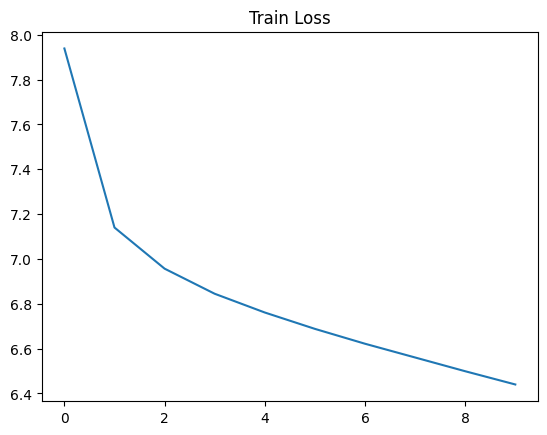

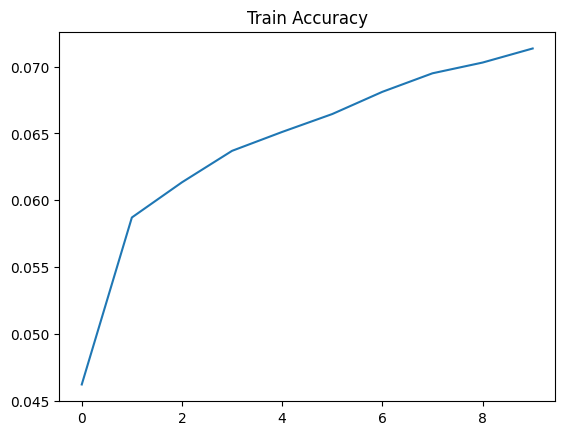

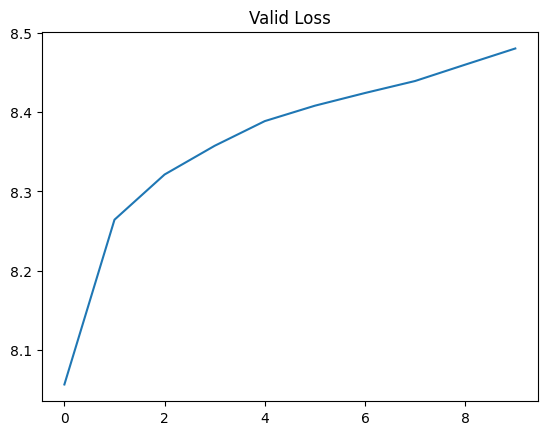

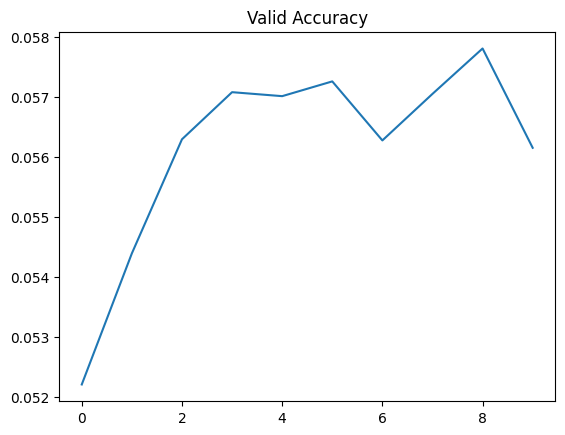

In [40]:
import matplotlib.pyplot as plt
plt.plot(range(10), train_loss_list)
plt.title("Train Loss")
plt.show()

plt.plot(range(10), train_acc_list)
plt.title("Train Accuracy")
plt.show()

plt.plot(range(10), valid_loss_list)
plt.title("Valid Loss")
plt.show()

plt.plot(range(10), valid_acc_list)
plt.title("Valid Accuracy")
plt.show()

In [52]:
from torch import tensor
embd = nn.Embedding(3, 5)
embd(tensor([1, 0, 0]))

tensor([[ 0.2915,  0.4098, -0.2013, -1.0609, -0.5993],
        [-1.3359,  0.0406,  0.9137, -0.6422,  0.3671],
        [-1.3359,  0.0406,  0.9137, -0.6422,  0.3671]],
       grad_fn=<EmbeddingBackward0>)